In [47]:
# basic python
import random
from pathlib import Path

# data science libraries
import numpy as np
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt

import sys
sys.path.append('../')  # to import from parent directory

from conformal_clustering.utils import ConformalClustering, label_alignment
from sklearn.model_selection import train_test_split


from sklearn.manifold import TSNE  
 
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from matplotlib import colors as mcolors

### Helper function for heatmaps

In [48]:
def lighten_toward_white(rgb, alpha):
    """alpha in [0,1]: 0 = no change, 1 = white."""
    return (1 - alpha) * rgb + alpha * 1.0

def labels_to_color(labels_like, n_classes=5, base_alpha=0.05):
    """
    - If labels_like is an int -> use that core color.
    - If it's an iterable -> take the mean of the cores in it,
      then 'intensify by number of labels' by moving toward white
      with alpha = base_alpha * (k-1), where k = set size.
      (More labels -> lighter background.) 
    """
    # normalize to a Python set of ints
    if isinstance(labels_like, (int, np.integer)):
        S = {int(labels_like)}
    else:
        S = {int(x) for x in labels_like}
        

    # empty set -> white
    if len(S) == 0:
        return np.array([1.0, 1.0, 1.0], float)

    # mean of the present cores
    mean_rgb = np.mean([core_rgb[i] for i in S], axis=0)

    # intensity control by subset size k
    k = len(S)
    alpha = min(1.0, base_alpha * (k - 1))  # more labels -> lighter
    return lighten_toward_white(mean_rgb, alpha)

def make_category_palette(categories):
    pool = [
        "#1affb7","#dd74ed","#ff7f00","#ffff21","#b1c5f3","#ffbbdf","#4F72FF",
        "#42ebf7","#fc8d62","#4daf4a","#88CCEE","#e78ac3","#ffd92f","#e5c494","#b3b3b3",
        "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f",
        "#bcbd22","#17becf","#e41a1c","#377eb8",
        "#332288","#117733","#44AA99","#a65628","#DDCC77","#CC6677","#AA4499","#882255","#999933"
    ]
    if len(categories) > len(pool):
        raise ValueError(f"Need {len(categories)} colors, but pool has only {len(pool)}.")
    palette = {cat: pool[i] for i, cat in enumerate(categories)}
    cmap = ListedColormap([palette[cat] for cat in categories])
    return palette, cmap

# -----------------------------
# Plot styling helper
# -----------------------------
def style_ax(ax):
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_alpha(0.8)
    ax.set_xlabel("T-SNE 1")
    ax.set_ylabel("T-SNE 2")

K = 8
palette, hydra_cmap = make_category_palette(np.arange(20))
core_rgb = {k: np.array(mcolors.to_rgb(v), float) for k, v in palette.items()}

# --- 6) Define dark colors for training points ---
def darken(rgb, factor=0.15):  # 0.15 = 15% darker
    return np.clip(rgb * (1 - factor), 0, 1)

dark_colors = {k: darken(core_rgb[k], 0.15) for k in core_rgb}

## Loading the data

Here, we would use the features that has been used in the final analysis of the workflow paper and has been recommended for further downstream analysis.


In [49]:
# Try to locate the repo root by searching upwards for "Reproducible_Code"
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / "Reproducible_Code").exists()), None)

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the 'Reproducible_Code' folder by searching parents of the current working directory. "
        "Set repo_root manually or run the notebook from within the repository."
    )

data_path = repo_root / "Reproducible_Code" / "Data" / "astro_scaled_mean_imputed_with_ids_all.csv"
labels_path = repo_root / "Reproducible_Code" / "Data" / "cluster_labels_final.csv"

X = pd.read_csv(data_path)
X = pd.DataFrame(X)

y = pd.read_csv(labels_path)
y = pd.DataFrame(y)

merged_df = pd.merge(X, y, on='APOGEE_ID')
merged_df['cluster'] = merged_df['cluster'] - 1 # Adjust cluster labels to start from 0 for our algorithm's convention

# 11 “medium” astro features used in the paper
cols = [
    "FE_H",   # [Fe/H]
    "MG_FE",  # [Mg/Fe]
    "O_FE",   # [O/Fe]
    "SI_FE",  # [Si/Fe]
    "CA_FE",  # [Ca/Fe]
    "NI_FE",  # [Ni/Fe]
    "AL_FE",  # [Al/Fe]
    "C_FE",   # [C/Fe]
    "MN_FE",  # [Mn/Fe]
    "N_FE",   # [N/Fe]
    "K_FE",   # [K/Fe]
    "cluster", # cluster labels
    "split", # split info (train/calib/test)
]

# keep a separate, feature+meta subset; do NOT overwrite merged_df
astro_subset = merged_df.loc[:, cols].copy()

is_test = astro_subset["split"].str.lower() == "test"

# Features only (no split column available in merged_df)
X_astro = astro_subset.drop(columns=["cluster", "split"]).copy()
y_astro = astro_subset["cluster"].values 

X_test = X_astro.loc[is_test].copy()  # final holdout
X_rest = X_astro.loc[~is_test].copy()  # to be split into train/calib

y_test = y_astro[is_test.values]
y_rest = y_astro[~is_test.values]

# 2) Split the remaining data into Train + Calibration
# We pass index array to get tr_idx and cal_idx
X_train, X_calib, y_train, y_calib, tr_idx, cal_idx = train_test_split(
    X_rest,
    y_rest,
    np.arange(len(X_rest)),
    test_size=0.5,
    random_state=0,
    # stratify=y_rest,
)

print("Shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_calib:", X_calib.shape, " y_calib:", y_calib.shape)
print("  X_test:", X_test.shape, " y_test:", y_test.shape)

Shapes:
  X_train: (1314, 11)  y_train: (1314,)
  X_calib: (1314, 11)  y_calib: (1314,)
  X_test: (658, 11)  y_test: (658,)


### Split-CC in the original covariate space

We would apply our Split-CC algorithm on the original covariates. Then we would use a dimension reduction method to plot the points into a low-dimensonal space for visualization. From the recommendation of the paper, we would use T-SNE with perplexity $100$ to project it down to the 2-dimensional space. Then We would plot the set-valued outputs for test points in a color-coded fashion.

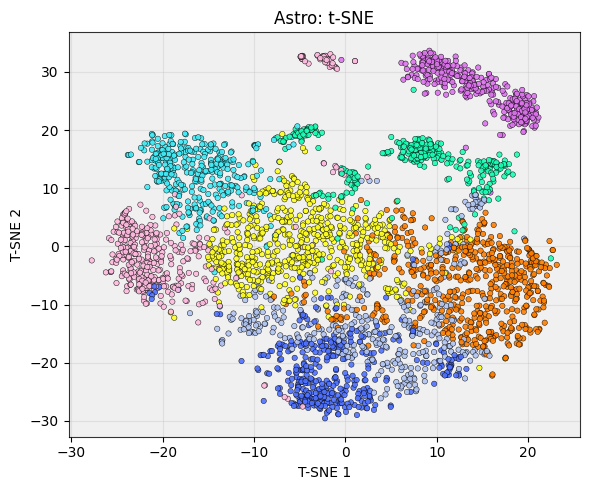

In [50]:
# TSNE visualization of the astro data
X = np.asarray(X_astro, dtype=float)
T = TSNE(n_components=2, perplexity=100, random_state=0)
X_tsne = T.fit_transform(X) 

plt.figure(figsize=(6,5))
style_ax(plt.gca())
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=[core_rgb[label] for label in y_astro],
    s=15, alpha=0.9, marker="o",
    edgecolors="black", linewidths=0.35, rasterized=True
)
plt.title("Astro: t-SNE")
plt.tight_layout()
plt.show()

## Applying Fuzzy c-means stochastic

Since the workflow paper analyzed the dataset and recommnded K-means, the closest stochastic version we have is the fuzzy c-means

### Original dimension

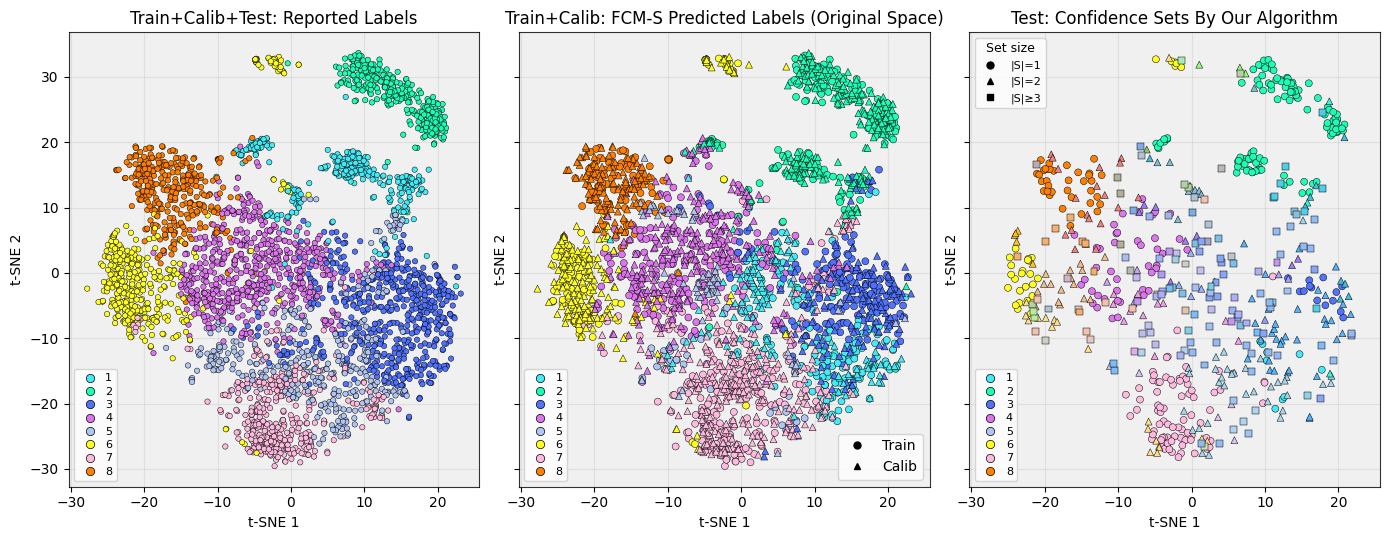

In [51]:
## Run the Split-CC algorithm on the data

K = 8  # Set number of clusters
alpha = 0.1

cc = ConformalClustering(X_train, X_calib, alpha=alpha)
# cc.set_classifier('SVC', C=0.50, probability=True)
cc.set_classifier('RF', random_state=0)
cc.fit('FCMS', c=K, m=1.1, error=0.005, maxiter=1000, seed=10)
# cc.fit('GMMS', n_components=K, n_init=20, init_params='k-means++')

oracle_alignment_original = label_alignment(cc.y_tr, y_train, K)

# -----------------------------
# Data + conformal sets
# -----------------------------
X_tsne_rest = X_tsne[~is_test].copy()
X_tsne_test = X_tsne[is_test].copy()
X_tsne_train = X_tsne_rest[tr_idx].copy()
X_tsne_calib = X_tsne_rest[cal_idx].copy()

predictions_boolean_rest = cc.conformal_set(X_rest)
predictions_boolean_test = cc.conformal_set(X_test)

# Colors for split-CC plots (use your labels_to_color)
rest_colors = np.array([
    labels_to_color(np.where(predictions_boolean_rest[i])[0])
    for i in range(predictions_boolean_rest.shape[0])
])
test_colors = np.array([
    labels_to_color(np.where(predictions_boolean_test[i])[0])
    for i in range(predictions_boolean_test.shape[0])
])

# True-label colors (use your core_rgb + oracle_alignment mapping)
true_colors_all = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_astro])
true_colors_rest = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_rest])
true_colors_test = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_test])

# Legend handles (true labels) -- unify across both splits so legend is consistent
all_unique_labels = np.unique(np.concatenate([y_rest, y_test])).astype(int)
true_handles = [
    Line2D([0], [0], marker='o', linestyle='none',
           markersize=6,
           markerfacecolor=core_rgb[int(oracle_alignment_original[lab])],
           markeredgecolor='k', markeredgewidth=0.5,
           label=str(lab + 1))
    for lab in all_unique_labels
]

# Set-size legend handles (all black)
setsize_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|=1'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|=2'),
    Line2D([0],[0], marker='s', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|≥3'),
]

# Train/calib marker grouping helper
tc_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Train'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Calib'),
]

# Marker grouping helper
def marker_group_from_boolean(pred_bool):
    set_sizes = pred_bool.sum(axis=1)
    return np.where(set_sizes == 1, 1, np.where(set_sizes == 2, 2, 3))

marker_map = {1: "o", 2: "^", 3: "s"}
marker_group_rest = marker_group_from_boolean(predictions_boolean_rest)
marker_group_test = marker_group_from_boolean(predictions_boolean_test)

# -----------------------------
# Plot styling helper
# -----------------------------
def style_ax(ax):
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_alpha(0.8)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# -----------------------------
# 4-panel figure
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

# Panel 1: Train+Calib true
ax = axes[0]
style_ax(ax)
ax.set_title("Train+Calib+Test: Reported Labels")
ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=true_colors_all, s=15, alpha=0.99, marker="o",
    edgecolors="black", linewidths=0.35, rasterized=True
)
ax.legend(handles=true_handles, loc="lower left",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# Panel 2: Train+Calib split-CC
ax = axes[1]
style_ax(ax)
ax.set_title("Train+Calib: FCM-S Predicted Labels (Original Space)")
ax.scatter(
    X_tsne_train[:, 0], X_tsne_train[:, 1],
    s=25, alpha=0.99, marker="o",
    color = [core_rgb[k] for k in cc.y_tr],  # color by true label
    edgecolors="black", linewidths=0.35, rasterized=True
)
ax.scatter(
    X_tsne_calib[:, 0], X_tsne_calib[:, 1],
    s=25, alpha=0.99, marker="^",
    color = [core_rgb[k] for k in cc.y_cal_al],  # color by true label
    edgecolors="black", linewidths=0.35, rasterized=True
)
leg_set = ax.legend(handles=tc_handles, 
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax.add_artist(leg_set)
ax.legend(handles=true_handles, loc="lower left",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# # Panel 3: Test true
# ax = axes[2]
# style_ax(ax)
# ax.set_title("Test: Reported labels")
# ax.scatter(
#     X_tsne_test[:, 0], X_tsne_test[:, 1],
#     c=true_colors_test, s=25, alpha=0.99, marker="o",
#     edgecolors="black", linewidths=0.35, rasterized=True
# )
# ax.legend(handles=true_handles, loc="lower left",
#           frameon=True, fontsize=8, title_fontsize=9,
#           borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# Panel 4: Test split-CC
ax = axes[2]
style_ax(ax)
ax.set_title("Test: Confidence Sets By Our Algorithm")
for g in [1, 2, 3]:
    idx = (marker_group_test == g)
    ax.scatter(
        X_tsne_test[idx, 0], X_tsne_test[idx, 1],
        c=test_colors[idx], s=25, alpha=0.99, marker=marker_map[g],
        edgecolors="black", linewidths=0.35, rasterized=True
    )
leg_set = ax.legend(handles=setsize_handles, title="Set size",
                    loc="upper left", frameon=True, fontsize=8, title_fontsize=9)
ax.add_artist(leg_set)
ax.legend(handles=true_handles, loc="lower left",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

fig.tight_layout()
plt.savefig("Figures/ASTRO_original_space_FCMS.pdf", bbox_inches='tight')
plt.show()

### Projected space

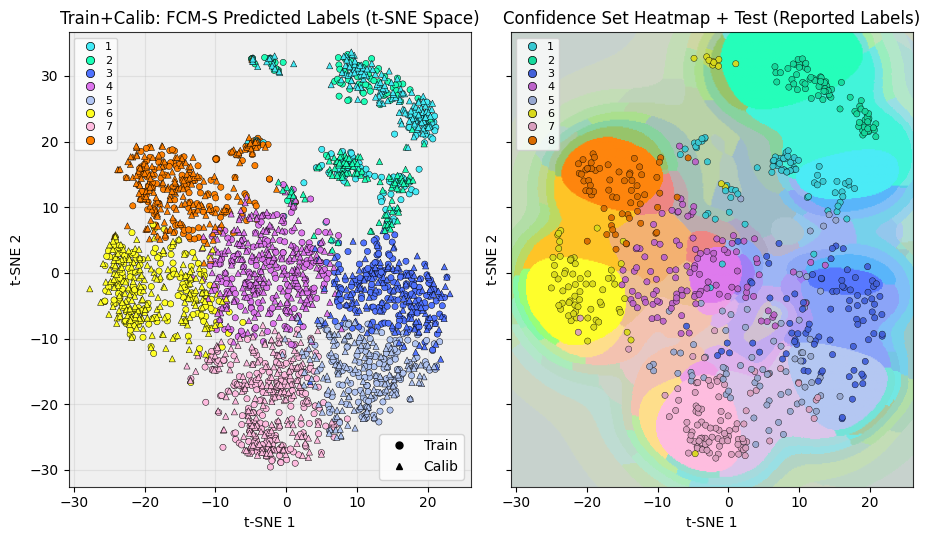

In [52]:
# X_tsne_train, X_tsne_calib, y_tsne_train, y_tsne_calib = train_test_split(
#     X_tsne_rest, y_rest, test_size=0.5, random_state=0,
#     # stratify=y_astro
# )
X_tsne_train = X_tsne_rest[tr_idx].copy()
X_tsne_calib = X_tsne_rest[cal_idx].copy()

x_min = min(X_tsne_train[:, 0].min(), X_tsne_calib[:, 0].min(), (X_tsne_test[:, 0].min() if len(X_tsne_test) else np.inf)) - 3
x_max = max(X_tsne_train[:, 0].max(), X_tsne_calib[:, 0].max(), (X_tsne_test[:, 0].max() if len(X_tsne_test) else -np.inf)) + 3
y_min = min(X_tsne_train[:, 1].min(), X_tsne_calib[:, 1].min(), (X_tsne_test[:, 1].min() if len(X_tsne_test) else np.inf)) - 3
y_max = max(X_tsne_train[:, 1].max(), X_tsne_calib[:, 1].max(), (X_tsne_test[:, 1].max() if len(X_tsne_test) else -np.inf)) + 3

K = 8  # Set number of clusters
alpha = 0.1
# C=0.017/error=0.001/seed=12/m=1.238 --- IGNORE ---
cc = ConformalClustering(X_tsne_train, X_tsne_calib, alpha=alpha)
cc.set_classifier('SVC', kernel='rbf', C=0.015645, probability=True, random_state=1)
# cc.set_classifier('RF')
cc.fit('FCMS', c=K, m=1.26, error=0.0001, maxiter=1000, seed=103)
# cc.fit('Hier', n_clusters=K, linkage='ward')
# cc.fit('KM', n_clusters=K)
# cc.fit('GMMS', n_components=K, n_init=20, init_params='k-means++', random_state=0)

oracle_alignment_projected = label_alignment(cc.y_tr, y_train, K)

oracle_alignment_original = oracle_alignment_original.astype(int)
oracle_alignment_projected = oracle_alignment_projected.astype(int)

# Invert projected: projected -> train
inv_oracle_alignment_projected = np.empty(K, dtype=int)
inv_oracle_alignment_projected[oracle_alignment_projected] = np.arange(K, dtype=int)

# Compose: projected -> train -> original
oracle_alignment_projected_matched_to_original = (
    oracle_alignment_original[inv_oracle_alignment_projected]
)

res = 400
# 1. Define the grid 
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))  # (N, 2)

predictions_boolean = cc.conformal_set(grid_points)


true_colors_rest = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_rest])

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(28/3, 5.5),
    sharex=True, sharey=True
)
fig.patch.set_facecolor("white")

# ============================================================
# LEFT: Train+Calib true labels
# ============================================================
# style_ax(ax_left)
# ax_left.set_title("Train+Calib: Reported labels")

# ax_left.scatter(
#     X_tsne_rest[:, 0], X_tsne_rest[:, 1],
#     c=true_colors_rest,
#     s=15, alpha=0.99, marker="o",
#     edgecolors="black", linewidths=0.35,
#     rasterized=True
# )

# true_handles = [
#     Line2D([0], [0], marker='o', linestyle='none',
#            markersize=6,
#            markerfacecolor=core_rgb[int(oracle_alignment_original[lab])],
#            markeredgecolor='k', markeredgewidth=0.5,
#            label=str(lab+1))
#     for lab in all_unique_labels
# ]

# ax_left.legend(
#     handles=true_handles,
#     loc="best",
#     frameon=True,
#     fontsize=8,
#     title_fontsize=9,
#     borderpad=0.4,
#     labelspacing=0.3,
#     handletextpad=0.4
# )

# ============================================================
# MIDDLE: Heatmap
# ============================================================
style_ax(ax_left)
ax_left.set_title("Train+Calib: FCM-S Predicted Labels (t-SNE Space)")

ax_left.scatter(X_tsne_train[:, 0], X_tsne_train[:, 1],
               c=[core_rgb[k] for k in oracle_alignment_projected_matched_to_original[cc.y_tr]],
               s=20, alpha=0.99, marker="o",
               edgecolors="black", linewidths=0.35,
               rasterized=True
)
ax_left.scatter(X_tsne_calib[:, 0], X_tsne_calib[:, 1],
               c=[core_rgb[k] for k in oracle_alignment_projected_matched_to_original[cc.y_cal_al]],
               s=20, alpha=0.99, marker="^",
               edgecolors="black", linewidths=0.35,
               rasterized=True
)
    
# Train/calib marker grouping helper
tc_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Train'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Calib'),
]
leg_set = ax_left.legend(handles=tc_handles,
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax_left.add_artist(leg_set)
ax_left.legend(
    handles=true_handles,
    loc="best",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    borderpad=0.4,
    labelspacing=0.3,
    handletextpad=0.4
)

# ============================================================
# RIGHT: Heatmap + test points overlay
# ============================================================
# Build heatmap colors
color_grid = np.array([
    labels_to_color(
        oracle_alignment_projected_matched_to_original[
            np.where(predictions_boolean[i])[0].astype(int)
        ]
    )
    for i in range(predictions_boolean.shape[0])
]).reshape((res, res, 3))

# Match styling (but keep imshow visible)
ax_right.set_facecolor("#f0f0f0")
ax_right.grid(False)
ax_right.set_axisbelow(True)
for sp in ax_right.spines.values():
    sp.set_alpha(0.8)

ax_right.set_title("Confidence Set Heatmap + Test (Reported Labels)")

ax_right.imshow(
    color_grid,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    aspect="auto",
    alpha=0.95
)

ax_right.scatter(
    X_tsne_test[:, 0], X_tsne_test[:, 1],
    s=20,
    color=[dark_colors[k] for k in oracle_alignment_original[y_test]],
    edgecolors="black",
    linewidths=0.3,
    alpha=0.95,
    rasterized=True
)

# Legend for test true labels
unique_labels_test = np.unique(y_test).astype(int)
handles_hm = [
    Line2D([0], [0], marker='o', linestyle='none',
           markersize=6,
           markerfacecolor=dark_colors[int(oracle_alignment_original[lab])],
           markeredgecolor='k', markeredgewidth=0.5,
           label=str(lab+1))
    for lab in unique_labels_test
]
ax_right.legend(
    handles=handles_hm,
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    borderpad=0.4,
    labelspacing=0.3,
    handletextpad=0.4
)

ax_right.set_xlim(x_min, x_max)
ax_right.set_ylim(y_min, y_max)
ax_right.set_xlabel("t-SNE 1")
ax_right.set_ylabel("t-SNE 2")

fig.tight_layout()
plt.savefig("Figures/ASTRO_projected_space_FCMS.pdf", bbox_inches='tight')
plt.show()

## Applying GMM stochastic

Since our paper gives guarantees for the parmatric mixture model, we apply GMM stochatic to see the results here.

### Original dimension

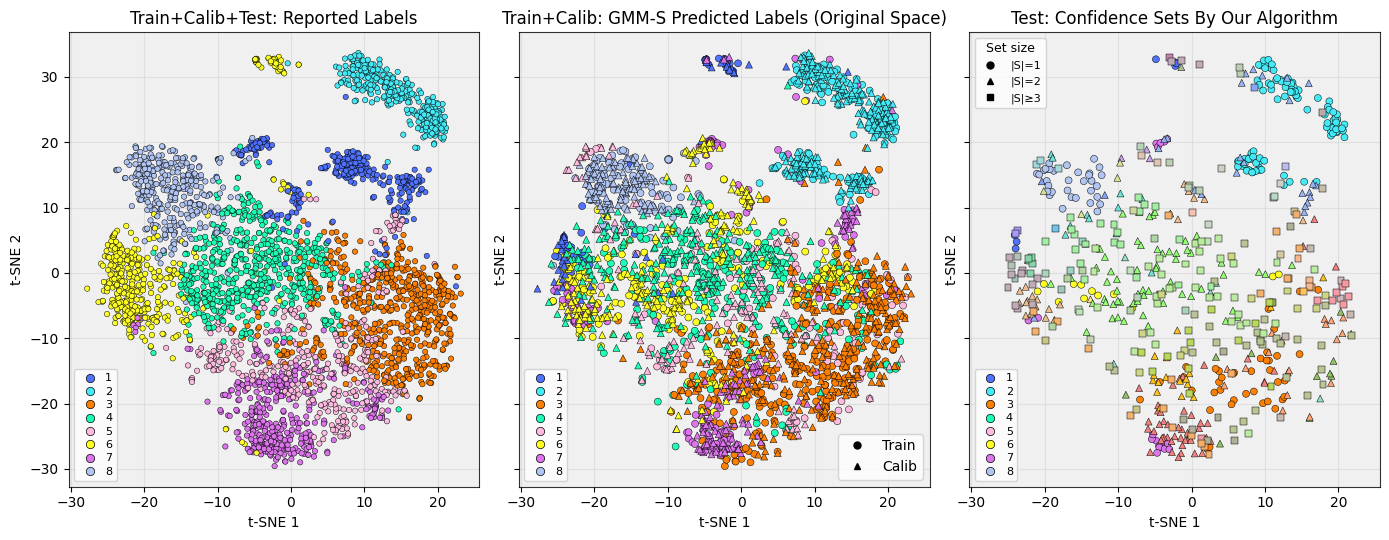

In [53]:
## Run the Split-CC algorithm on the data

K = 8  # Set number of clusters
alpha = 0.1

cc = ConformalClustering(X_train, X_calib, alpha=alpha)
# cc.set_classifier('SVC', C=0.50, probability=True)
cc.set_classifier('RF', random_state=0)
# cc.fit('FCMS', c=K, m=1.25, error=0.005, maxiter=1000, seed=10)
cc.fit('GMMS', n_components=K, n_init=20, init_params='k-means++', random_state=0)

oracle_alignment_original = label_alignment(cc.y_tr, y_train, K)

# -----------------------------
# Data + conformal sets
# -----------------------------
X_tsne_rest = X_tsne[~is_test].copy()
X_tsne_test = X_tsne[is_test].copy()
X_tsne_train = X_tsne_rest[tr_idx].copy()
X_tsne_calib = X_tsne_rest[cal_idx].copy()

predictions_boolean_rest = cc.conformal_set(X_rest)
predictions_boolean_test = cc.conformal_set(X_test)

# Colors for split-CC plots (use your labels_to_color)
rest_colors = np.array([
    labels_to_color(np.where(predictions_boolean_rest[i])[0])
    for i in range(predictions_boolean_rest.shape[0])
])
test_colors = np.array([
    labels_to_color(np.where(predictions_boolean_test[i])[0])
    for i in range(predictions_boolean_test.shape[0])
])

# True-label colors (use your core_rgb + oracle_alignment mapping)
true_colors_all = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_astro])
true_colors_rest = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_rest])
true_colors_test = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_test])

# Legend handles (true labels) -- unify across both splits so legend is consistent
all_unique_labels = np.unique(np.concatenate([y_rest, y_test])).astype(int)
true_handles = [
    Line2D([0], [0], marker='o', linestyle='none',
           markersize=6,
           markerfacecolor=core_rgb[int(oracle_alignment_original[lab])],
           markeredgecolor='k', markeredgewidth=0.5,
           label=str(lab + 1))
    for lab in all_unique_labels
]

# Set-size legend handles (all black)
setsize_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|=1'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|=2'),
    Line2D([0],[0], marker='s', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|≥3'),
]

# Train/calib marker grouping helper
tc_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Train'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Calib'),
]

# Marker grouping helper
def marker_group_from_boolean(pred_bool):
    set_sizes = pred_bool.sum(axis=1)
    return np.where(set_sizes == 1, 1, np.where(set_sizes == 2, 2, 3))

marker_map = {1: "o", 2: "^", 3: "s"}
marker_group_rest = marker_group_from_boolean(predictions_boolean_rest)
marker_group_test = marker_group_from_boolean(predictions_boolean_test)

# -----------------------------
# Plot styling helper
# -----------------------------
def style_ax(ax):
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_alpha(0.8)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# -----------------------------
# 4-panel figure
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

# Panel 1: Train+Calib true
ax = axes[0]
style_ax(ax)
ax.set_title("Train+Calib+Test: Reported Labels")
ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=true_colors_all, s=15, alpha=0.99, marker="o",
    edgecolors="black", linewidths=0.35, rasterized=True
)
ax.legend(handles=true_handles, loc="lower left",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# Panel 2: Train+Calib split-CC
ax = axes[1]
style_ax(ax)
ax.set_title("Train+Calib: GMM-S Predicted Labels (Original Space)")
ax.scatter(
    X_tsne_train[:, 0], X_tsne_train[:, 1],
    s=25, alpha=0.99, marker="o",
    color = [core_rgb[k] for k in cc.y_tr],  # color by true label
    edgecolors="black", linewidths=0.35, rasterized=True
)
ax.scatter(
    X_tsne_calib[:, 0], X_tsne_calib[:, 1],
    s=25, alpha=0.99, marker="^",
    color = [core_rgb[k] for k in cc.y_cal_al],  # color by true label
    edgecolors="black", linewidths=0.35, rasterized=True
)
leg_set = ax.legend(handles=tc_handles, 
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax.add_artist(leg_set)
ax.legend(handles=true_handles, loc="lower left",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# # Panel 3: Test true
# ax = axes[2]
# style_ax(ax)
# ax.set_title("Test: Reported labels")
# ax.scatter(
#     X_tsne_test[:, 0], X_tsne_test[:, 1],
#     c=true_colors_test, s=25, alpha=0.99, marker="o",
#     edgecolors="black", linewidths=0.35, rasterized=True
# )
# ax.legend(handles=true_handles, loc="lower left",
#           frameon=True, fontsize=8, title_fontsize=9,
#           borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# Panel 4: Test split-CC
ax = axes[2]
style_ax(ax)
ax.set_title("Test: Confidence Sets By Our Algorithm")
for g in [1, 2, 3]:
    idx = (marker_group_test == g)
    ax.scatter(
        X_tsne_test[idx, 0], X_tsne_test[idx, 1],
        c=test_colors[idx], s=25, alpha=0.99, marker=marker_map[g],
        edgecolors="black", linewidths=0.35, rasterized=True
    )
leg_set = ax.legend(handles=setsize_handles, title="Set size",
                    loc="upper left", frameon=True, fontsize=8, title_fontsize=9)
ax.add_artist(leg_set)
ax.legend(handles=true_handles, loc="lower left",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

fig.tight_layout()
plt.savefig("Figures/ASTRO_original_space_GMMS.pdf", bbox_inches='tight')
plt.show()

### Projected space

Since we do not have any prior analysis for which would be the most applicable cllustering method here, I went with the most standard GMMS. It is possible that from the stability analysis, some other clustering method might be better.

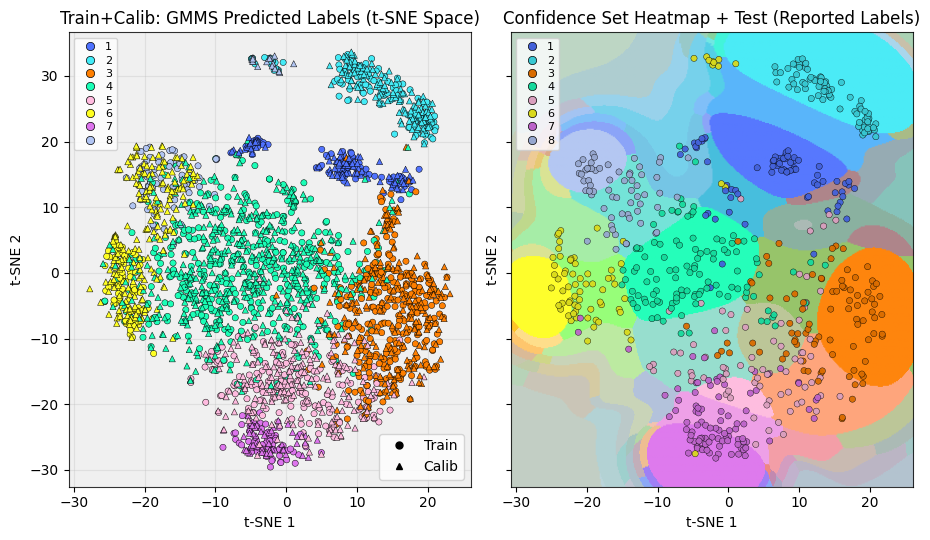

In [ ]:
# X_tsne_train, X_tsne_calib, y_tsne_train, y_tsne_calib = train_test_split(
#     X_tsne_rest, y_rest, test_size=0.5, random_state=0,
#     # stratify=y_astro
# )
X_tsne_train = X_tsne_rest[tr_idx].copy()
X_tsne_calib = X_tsne_rest[cal_idx].copy()

x_min = min(X_tsne_train[:, 0].min(), X_tsne_calib[:, 0].min(), (X_tsne_test[:, 0].min() if len(X_tsne_test) else np.inf)) - 3
x_max = max(X_tsne_train[:, 0].max(), X_tsne_calib[:, 0].max(), (X_tsne_test[:, 0].max() if len(X_tsne_test) else -np.inf)) + 3
y_min = min(X_tsne_train[:, 1].min(), X_tsne_calib[:, 1].min(), (X_tsne_test[:, 1].min() if len(X_tsne_test) else np.inf)) - 3
y_max = max(X_tsne_train[:, 1].max(), X_tsne_calib[:, 1].max(), (X_tsne_test[:, 1].max() if len(X_tsne_test) else -np.inf)) + 3

K = 8  # Set number of clusters
alpha = 0.1

cc = ConformalClustering(X_tsne_train, X_tsne_calib, alpha=alpha)
cc.set_classifier('SVC', C=0.025, probability=True, random_state=0)
# cc.set_classifier('RF')
# cc.fit('FCMS', c=K, m=1.5, error=0.005, maxiter=1000)
# cc.fit('KM', n_clusters=K)
cc.fit('GMMS', n_components=K, n_init=20, init_params='k-means++', random_state=30) # working rs = 1,15,16

oracle_alignment_projected = label_alignment(cc.y_tr, y_train, K)

oracle_alignment_original = oracle_alignment_original.astype(int)
oracle_alignment_projected = oracle_alignment_projected.astype(int)

# Invert projected: projected -> train
inv_oracle_alignment_projected = np.empty(K, dtype=int)
inv_oracle_alignment_projected[oracle_alignment_projected] = np.arange(K, dtype=int)

# Compose: projected -> train -> original
oracle_alignment_projected_matched_to_original = (
    oracle_alignment_original[inv_oracle_alignment_projected]
)

res = 400
# 1. Define the grid 
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))  # (N, 2)

predictions_boolean = cc.conformal_set(grid_points)


true_colors_rest = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_rest])

fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(28/3, 5.5),
    sharex=True, sharey=True
)
fig.patch.set_facecolor("white")

# ============================================================
# LEFT: Train+Calib true labels
# ============================================================
# style_ax(ax_left)
# ax_left.set_title("Train+Calib: Reported labels")

# ax_left.scatter(
#     X_tsne_rest[:, 0], X_tsne_rest[:, 1],
#     c=true_colors_rest,
#     s=15, alpha=0.99, marker="o",
#     edgecolors="black", linewidths=0.35,
#     rasterized=True
# )

# true_handles = [
#     Line2D([0], [0], marker='o', linestyle='none',
#            markersize=6,
#            markerfacecolor=core_rgb[int(oracle_alignment_original[lab])],
#            markeredgecolor='k', markeredgewidth=0.5,
#            label=str(lab+1))
#     for lab in all_unique_labels
# ]

# ax_left.legend(
#     handles=true_handles,
#     loc="best",
#     frameon=True,
#     fontsize=8,
#     title_fontsize=9,
#     borderpad=0.4,
#     labelspacing=0.3,
#     handletextpad=0.4
# )

# ============================================================
# MIDDLE: Heatmap
# ============================================================
style_ax(ax_left)
ax_left.set_title("Train+Calib: GMMS Predicted Labels (t-SNE Space)")

ax_left.scatter(X_tsne_train[:, 0], X_tsne_train[:, 1],
               c=[core_rgb[k] for k in oracle_alignment_projected_matched_to_original[cc.y_tr]],
               s=20, alpha=0.99, marker="o",
               edgecolors="black", linewidths=0.35,
               rasterized=True
)
ax_left.scatter(X_tsne_calib[:, 0], X_tsne_calib[:, 1],
               c=[core_rgb[k] for k in oracle_alignment_projected_matched_to_original[cc.y_cal_al]],
               s=20, alpha=0.99, marker="^",
               edgecolors="black", linewidths=0.35,
               rasterized=True
)
    
# Train/calib marker grouping helper
tc_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Train'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Calib'),
]
leg_set = ax_left.legend(handles=tc_handles,
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax_left.add_artist(leg_set)
ax_left.legend(
    handles=true_handles,
    loc="best",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    borderpad=0.4,
    labelspacing=0.3,
    handletextpad=0.4
)

# ============================================================
# RIGHT: Heatmap + test points overlay
# ============================================================
# Build heatmap colors
color_grid = np.array([
    labels_to_color(
        oracle_alignment_projected_matched_to_original[
            np.where(predictions_boolean[i])[0].astype(int)
        ]
    )
    for i in range(predictions_boolean.shape[0])
]).reshape((res, res, 3))

# Match styling (but keep imshow visible)
ax_right.set_facecolor("#f0f0f0")
ax_right.grid(False)
ax_right.set_axisbelow(True)
for sp in ax_right.spines.values():
    sp.set_alpha(0.8)

ax_right.set_title("Confidence Set Heatmap + Test (Reported Labels)")

ax_right.imshow(
    color_grid,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    aspect="auto",
    alpha=0.95
)

ax_right.scatter(
    X_tsne_test[:, 0], X_tsne_test[:, 1],
    s=20,
    color=[dark_colors[k] for k in oracle_alignment_original[y_test]],
    edgecolors="black",
    linewidths=0.3,
    alpha=0.95,
    rasterized=True
)

# Legend for test true labels
unique_labels_test = np.unique(y_test).astype(int)
handles_hm = [
    Line2D([0], [0], marker='o', linestyle='none',
           markersize=6,
           markerfacecolor=dark_colors[int(oracle_alignment_original[lab])],
           markeredgecolor='k', markeredgewidth=0.5,
           label=str(lab+1))
    for lab in unique_labels_test
]
ax_right.legend(
    handles=handles_hm,
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    borderpad=0.4,
    labelspacing=0.3,
    handletextpad=0.4
)

ax_right.set_xlim(x_min, x_max)
ax_right.set_ylim(y_min, y_max)
ax_right.set_xlabel("t-SNE 1")
ax_right.set_ylabel("t-SNE 2")

fig.tight_layout()
plt.savefig("Figures/ASTRO_projected_space_GMMS.pdf", bbox_inches='tight')
plt.show()